# Testing local CTDS against Adithi's reference (Jha et al. 2024)

Reference repo vendored under [vendor/Cell_type_dynamical_system/](../vendor/Cell_type_dynamical_system/). Two packages live there, both installed editable into this venv via `uv sync --group ref`:
- **`ssm`** — Adithi's ssm fork with the `gaussian_ctds` dynamics + emissions classes.
- **`adithis_utils`** — her `utils/` directory, repackaged so it imports as `from adithis_utils.simulation_utils import ...`.

## Goals (single-region CTDS)

1. **Forward LL parity at ground truth** — push identical params into both models and confirm $\log p(Y\mid\theta_{\text{true}})$ matches.
2. **EM from random init** — fit both, compare LL trajectories, wall time, and recovered parameters.
3. **EM from NMF init** — same as 2 but with the constrained-regression + per-class NMF warm-start the paper uses.
4. **Sanity check** — start ssm at the ground-truth params and confirm Laplace-EM doesn't drift away.
5. **Aligned parameter recovery** — apply a single C-based linear alignment to both fits, report MSEs and side-by-side heatmaps.

## Conventions to keep straight

| | shape per trial | array form |
|---|---|---|
| ssm | `(T, N)` | list of `n_trials` arrays |
| local | `(T, N, 1)` | one `(n_trials, T, N, 1)` array |

Both `ssm.lds.LDS.log_likelihood` and `local.LL` return **per-(trial, timestep)** average LL — no extra normalization needed.

## 0. Setup

In [1]:
import time, warnings, pathlib
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

import ssm.lds as ssm_lds
from adithis_utils.simulation_utils import create_dynamics_matrix
from adithis_utils.nnmf_utils import obtain_params_nnmf_init

from pillow_lab_rotation.ctds import CTDS
from pillow_lab_rotation.ssm_patches import patch_ssm_ctds

if pathlib.Path('../JS.mplstyle').exists():
    plt.style.use('../JS.mplstyle')


## 1. Build a single-region ground-truth CTDS

Pick `Ne, Ni, De, Di, T, n_trials`. Build:
- $A$ via `create_dynamics_matrix(np.array([[De, Di]]))` — Dale's law, single region.
- $C$ as block-positive: top-left $N_e \times D_e$ block of `np.random.rand`, bottom-right $N_i \times D_i$ block of `np.random.rand`, zeros elsewhere.
- $Q$ small PD (e.g. random Wishart-ish, then divide by something so noise is small).
- $R$ small diagonal positive (e.g. `np.diag(rand) / 1000`).
- $\mu_0 = 0$, $Q_0 = I$.

Match the construction in [vendor/Cell_type_dynamical_system/fit_ctds_on_simulated_data.ipynb](../vendor/Cell_type_dynamical_system/fit_ctds_on_simulated_data.ipynb) so you're testing the same regime the paper uses. Print spectral radius of $A$ and PD-checks for $Q$, $R$.

In [2]:
Ne, Ni = 5, 5
N = Ne + Ni
De, Di = 2, 3
D = De + Di

# Single-region: list_of_dimensions has one row, two columns (E, I).
list_of_dimensions = np.array([[De, Di]])

np.random.seed(10)

# Dynamics A: Dale's law within region (no across-region terms in single-region case).
A_true = create_dynamics_matrix(list_of_dimensions)

# Emissions C: top-left Ne x De and bottom-right Ni x Di blocks positive, zeros elsewhere.
C_true = np.zeros((N, D))
C_true[:Ne, :De] = np.random.rand(Ne, De)
C_true[Ne:, De:] = np.random.rand(Ni, Di)

# Latent noise covariance (small, PD).
Q_true = np.random.randn(D, D)
Q_true = Q_true.T @ Q_true + np.eye(D)
Q_true = Q_true / (Q_true.max() * 100)

# Observation noise (diagonal, small, positive).
R_true = np.diag(np.random.rand(N) + 0.1) / 1000

# Initial state.
mu0_true = np.zeros((D, 1))
Q0_true = np.eye(D)

print('A spectral radius:', np.max(np.abs(np.linalg.eigvals(A_true))))
print('Q PD:', bool(np.all(np.linalg.eigvalsh(Q_true) > 0)))
print('R PD:', bool(np.all(np.diag(R_true) > 0)))

A spectral radius: 0.8992820255063975
Q PD: True
R PD: True


## 2. Build the reference model and sample synthetic data

**Build:** instantiate `ssm_lds.LDS(N=N, D=D, M=0, dynamics='gaussian_ctds', emissions='gaussian_ctds', emission_kwargs=..., dynamics_kwargs=...)`. The kwargs need:
- `cell_identity`: integer array of length $N$, `1` for E, `2` for I.
- `region_identity`: integer array of length $N$, all zeros for single region.
- `list_of_dimensions`: shape `(num_regions, 2)`, here `[[De, Di]]`.

**Push ground-truth params:** the relevant attributes are
- `m.dynamics.As[0]`, `m.dynamics.bs[0]`, `m.dynamics._sqrt_Sigmas[0] = chol(Q)`
- `m.dynamics.mu_init[0]`, `m.dynamics.Sigmas_init = np.array([Q0])`
- `m.emissions.Cs[0]`, `m.emissions.ds[0]`, `m.emissions.inv_etas[0] = R` (yes, `inv_etas` stores the covariance for `GaussianCellTypeEmissions` — see `vendor/Cell_type_dynamical_system/ssm/ssm/emissions.py:573`)

**Sample:** call `m.sample(T)` `n_trials` times. Each call returns `(states, data)` of shapes `(T, D)`, `(T, N)`. Build a list `datas` for ssm and a `(n_trials, T, N, 1)` array `Y_local` for your model.

In [3]:
# kwargs for the ssm CTDS model — single region.
cell_identity = np.array([1] * Ne + [2] * Ni)   # 1 = E, 2 = I (0 reserved for unknown)
region_identity = np.zeros(N, dtype=int)        # all neurons in region 0

emission_kwargs = dict(
    cell_identity=cell_identity,
    region_identity=region_identity,
    list_of_dimensions=list_of_dimensions,
)
dynamics_kwargs = dict(list_of_dimensions=list_of_dimensions)

Assuming Dale's constraints for the weights within regions
Assuming FOF-ADS cross-region constraints if 2 regions, otherwise no cross-region constraints


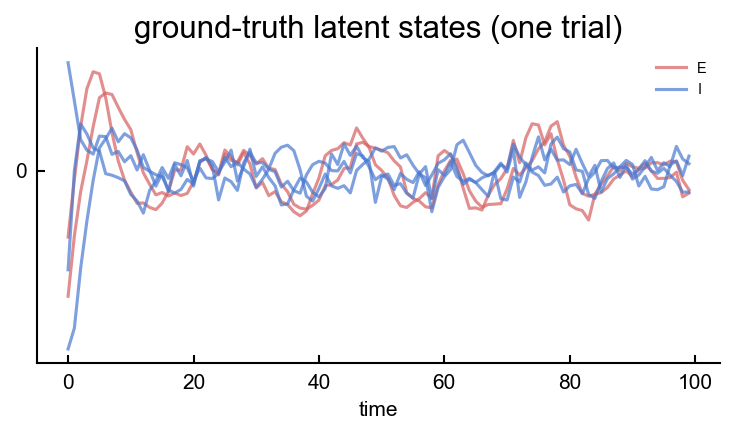

In [4]:
GROUND_TRUTH_MODEL = ssm_lds.LDS(
    N=N, D=D, M=0,
    dynamics='gaussian_ctds',
    emissions='gaussian_ctds',
    emission_kwargs=emission_kwargs,
    dynamics_kwargs=dynamics_kwargs,
)

# Push ground-truth params into the model — without this step ssm samples from
# random-init params instead of from A_true, C_true, etc.
GROUND_TRUTH_MODEL.dynamics.As[0] = A_true
GROUND_TRUTH_MODEL.dynamics.bs[0] = 0
GROUND_TRUTH_MODEL.dynamics._sqrt_Sigmas[0] = np.linalg.cholesky(Q_true)
GROUND_TRUTH_MODEL.emissions.Cs[0] = C_true
GROUND_TRUTH_MODEL.emissions.ds[0] = 0
GROUND_TRUTH_MODEL.emissions.inv_etas[0] = R_true  # `inv_etas` IS the covariance for GaussianCellTypeEmissions
assert np.allclose(GROUND_TRUTH_MODEL.dynamics.Sigmas[0], Q_true), 'Q not set correctly'

# Generate synthetic data from ground truth.
T = 100
num_trials = 50
datas = []
for _ in range(num_trials):
    true_states, data = GROUND_TRUTH_MODEL.sample(T, prefix=None)
    datas.append(data)

# Plot latent trajectories — E in red, I in blue.
fig, ax = plt.subplots(figsize=(5, 3))
for d in range(De):
    ax.plot(true_states[:, d], color='C3', alpha=0.7, label='E' if d == 0 else None)
for d in range(De, D):
    ax.plot(true_states[:, d], color='C0', alpha=0.7, label='I' if d == De else None)
ax.set(xlabel='time', title='ground-truth latent states (one trial)')
ax.set_yticks([0])
ax.set_yticklabels(['0'])
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()

In [5]:
# Adithi's model exactly as the vendored ssm fork provides it.
adithis_default = ssm_lds.LDS(
    N=N, D=D, M=0,
    dynamics='gaussian_ctds',
    emissions='gaussian_ctds',
    emission_kwargs=emission_kwargs,
    dynamics_kwargs=dynamics_kwargs,
)

# Same structure, but with the M-step bugs fixed (see §3a markdown). The patches
# replace cp.trace(A @ Var @ B) with cp.sum(cp.diag(...)) — CVXPY 1.8.1 silently
# evaluates the former as the Frobenius inner product — strip the MAP priors on
# Q/R, and write Q0 through _sqrt_Sigmas_init each iteration.
adithis_patched = ssm_lds.LDS(
    N=N, D=D, M=0,
    dynamics='gaussian_ctds',
    emissions='gaussian_ctds',
    emission_kwargs=emission_kwargs,
    dynamics_kwargs=dynamics_kwargs,
)
patch_ssm_ctds(adithis_patched)

# Match ssm's parametrization on the local side: fit observation bias d
# (her emissions.ds[0]), hold dynamics bias b at zero (ssm hard-zeros bs[k]
# every M-step), and hold mu0 fixed at zero (ssm uses mu_init = 0 with no
# inputs and does not update it).
jeremys_model = CTDS(
    De=De,
    Di=Di,
    Ne=Ne,
    Ni=Ni,
    fit_mu0=False,
    fit_b=False,
    fit_d_bias=True,
)
jeremys_model.mu0 = np.zeros((D, 1))


Assuming Dale's constraints for the weights within regions
Assuming FOF-ADS cross-region constraints if 2 regions, otherwise no cross-region constraints
Assuming Dale's constraints for the weights within regions
Assuming FOF-ADS cross-region constraints if 2 regions, otherwise no cross-region constraints


## 3. Forward LL parity at ground truth

- `ref_avg = ref_truth.log_likelihood(datas)` returns the per-(trial, T) average (it divides by `total_time_steps` internally — see `vendor/Cell_type_dynamical_system/ssm/ssm/lds.py:1010`).
- For local: instantiate a fresh `CTDS`, push the truth params, manually run one filter pass (set `local.observations = Y_local`, `local.n_trials, local.T = ...`, `local.inputs = zeros(...)`, then `local.run_filter()`), and read `local.LL`.

The two numbers should match to ~$10^{-10}$. If they don't, the gap is almost always in how the initial state $\mathcal{N}(\mu_0, Q_0)$ is treated at $t=1$.

In [6]:
def _push_truth_into_ssm(m):
    m.dynamics.As[0] = A_true
    m.dynamics.bs[0] = 0
    m.dynamics._sqrt_Sigmas[0] = np.linalg.cholesky(Q_true)
    m.emissions.Cs[0] = C_true
    m.emissions.ds[0] = 0
    m.emissions.inv_etas[0] = R_true

_push_truth_into_ssm(adithis_default)
_push_truth_into_ssm(adithis_patched)

# Push ground-truth params into Jeremy's model. Truth has bs=0 and ds=0, so push
# zeros explicitly to make the parity check independent of init.
jeremys_model.A = A_true.copy()
jeremys_model.C = C_true.copy()
jeremys_model.Q = Q_true.copy()
jeremys_model.R = R_true.copy()
jeremys_model.mu0 = mu0_true.copy()
jeremys_model.Q0 = Q0_true.copy()
jeremys_model.b = np.zeros((D, 1))
jeremys_model.d_bias = np.zeros((N, 1))


In [7]:
# Local model wants (n_trials, T, N, 1); ssm gives a list of (T, N).
Y_local = np.stack([d[..., None] for d in datas], axis=0)

ll_default = adithis_default.log_likelihood(datas)
ll_patched = adithis_patched.log_likelihood(datas)
ll_local = jeremys_model.predict(Y_local)[-1] / (Y_local.shape[0] * Y_local.shape[1])

print(f"Adithi default LL  (avg per trial-timestep): {ll_default:14.10f}")
print(f"Adithi patched LL  (avg per trial-timestep): {ll_patched:14.10f}")
print(f"Jeremy's LL        (avg per trial-timestep): {ll_local:14.10f}")
print(f'max abs diff                                : {max(abs(ll_default - ll_local), abs(ll_patched - ll_local)):.4e}')


Adithi default LL  (avg per trial-timestep):  17.3835293491
Adithi patched LL  (avg per trial-timestep):  17.3835293491
Jeremy's LL        (avg per trial-timestep):  17.3835293491
max abs diff                                : 3.9080e-14


# MODELS AGREE ON LL

## 3a. Structural M-step differences and how they're patched

The LL-parity check above confirms the **E-step** (filter / smoother) matches across all three models to ~1e-10. Past §3 the unpatched ssm produces different fits because of four structural M-step bugs:

1. **CVXPY 1.8.1 silently miscomputes `cp.trace(A @ Var @ B)`** — it returns the Frobenius inner product `sum((A @ Var) * B)` instead of the matrix trace. ssm's `_solve_constrained_A` uses this in the linear term of the QP, so the A update is solving the wrong objective. ([observations.py:1319](../vendor/Cell_type_dynamical_system/ssm/ssm/observations.py))

2. **MAP shrinkage on Q and R** instead of MLE. [`observations.py:1373`](../vendor/Cell_type_dynamical_system/ssm/ssm/observations.py) and [`regression.py:222`](../vendor/Cell_type_dynamical_system/ssm/ssm/regression.py) use
$$\Sigma = (\text{sqerr} + \Psi_0) \;/\; (\nu_0 + N + D + 1)$$
with `Psi0=1e-4, nu0=1e-4` by default. The local code uses MLE: `sqerr / N`.

3. **`Q0` is effectively never updated** in ssm. [`lds.py:973`](../vendor/Cell_type_dynamical_system/ssm/ssm/lds.py) makes `Sigmas_init` a property that returns a fresh array on every access; the M-step in `observations.py:1129` then does `self.Sigmas_init[k] = …`, which mutates that throwaway. Q0 stays at whatever you initialized it to. (Additionally, even if the setter worked, ssm uses only the last trial's `ExxT[0]` rather than averaging.)

4. **Tiny L2 ridge (`l2_penalty_A=1e-8`)** on the A QP. Negligible by itself but bundled with the fix.

The patches live in [`src/pillow_lab_rotation/ssm_patches.py`](../src/pillow_lab_rotation/ssm_patches.py). `patch_ssm_ctds(model)` monkey-patches the dynamics `_solve_constrained_A` (CVXPY workaround), dynamics `m_step` (MLE Q, proper Q0 update, no ridge), and emissions `m_step` (MLE R, no ridge) on an ssm instance.

Below we run **two ssm models alongside Jeremy's**: `adithis_default` (the vendored fork as-is) and `adithis_patched` (after `patch_ssm_ctds`). The default exhibits the structural gap. The patched version should track Jeremy's MLE fit to floating-point precision.


## 4. EM from random initialization

- Reference: fresh `make_ref_model()`, then `ref.fit(datas, method='laplace_em', num_iters=100, initialize=True)`. The `initialize=True` runs ssm's PCA + ARHMM init.
- Local: fresh `CTDS(...)`, `local.init_params()` (no args = random init), then `local.fit(Y_local, max_iter=100, verbose=False)`.

Time both, capture the LL trajectory from each, plot them on the same axes against the ground-truth LL line.

In [8]:
# Train/test split for the §4 and §5 fits.
num_train_trials = int(0.8 * num_trials)
train_datas = datas[:num_train_trials]
test_datas = datas[num_train_trials:]

# Exact LL of the ground-truth model on each split — useful as a reference
# line on the EM trajectories below.
true_model_train_LL = GROUND_TRUTH_MODEL.log_likelihood(train_datas)
true_model_test_LL  = GROUND_TRUTH_MODEL.log_likelihood(test_datas)
print(f'train trials: {len(train_datas)}, test trials: {len(test_datas)}')
print(f'true-model train LL: {true_model_train_LL:.6f}')
print(f'true-model test  LL: {true_model_test_LL:.6f}')


train trials: 40, test trials: 10
true-model train LL: 17.367428
true-model test  LL: 17.447936


In [10]:
adithis_default = ssm_lds.LDS(
    N=N, D=D, M=0,
    dynamics='gaussian_ctds',
    emissions='gaussian_ctds',
    emission_kwargs=emission_kwargs,
    dynamics_kwargs=dynamics_kwargs,
)
adithis_patched = ssm_lds.LDS(
    N=N, D=D, M=0,
    dynamics='gaussian_ctds',
    emissions='gaussian_ctds',
    emission_kwargs=emission_kwargs,
    dynamics_kwargs=dynamics_kwargs,
)
patch_ssm_ctds(adithis_patched)

jeremys_model = CTDS(
    De=De, Di=Di, Ne=Ne, Ni=Ni,
    fit_mu0=False, fit_b=False, fit_d_bias=True,
)
jeremys_model.init_params()
jeremys_model.mu0 = np.zeros((D, 1))

# Make all three start from the SAME init — push Jeremy's random-init params
# into both ssm models, then fit with initialize=False so ssm doesn't overwrite
# the shared starting point.
def _push_jeremys_init(m):
    m.dynamics.As[0] = jeremys_model.A
    m.dynamics.bs[0] = jeremys_model.b[:, 0]
    m.dynamics._sqrt_Sigmas[0] = np.linalg.cholesky(jeremys_model.Q)
    m.dynamics.mu_init[0] = jeremys_model.mu0[:, 0]
    m.dynamics.Sigmas_init = np.array([jeremys_model.Q0])
    m.emissions.Cs[0] = jeremys_model.C
    m.emissions.ds[0] = jeremys_model.d_bias[:, 0]
    m.emissions.inv_etas[0] = jeremys_model.R

_push_jeremys_init(adithis_default)
_push_jeremys_init(adithis_patched)

lls_default, _ = adithis_default.fit(train_datas, method="laplace_em", num_iters=100, initialize=False)
lls_patched, _ = adithis_patched.fit(train_datas, method="laplace_em", num_iters=100, initialize=False)

Y_train = np.stack([d[..., None] for d in train_datas], axis=0)
jeremys_model.fit(Y_train, verbose=True, criterion=1e-6)


Assuming Dale's constraints for the weights within regions
Assuming FOF-ADS cross-region constraints if 2 regions, otherwise no cross-region constraints
Assuming Dale's constraints for the weights within regions
Assuming FOF-ADS cross-region constraints if 2 regions, otherwise no cross-region constraints


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

var104401 [[153.36961877  35.63245492  31.33856127  34.08595829  28.81528945]
 [ 40.86868396   9.9680166    8.67544807   8.60072253   7.47901287]
 [ 33.92578989   8.20364108   6.4804578    6.68270448   5.74885043]
 [ 22.93613489   4.76038911   3.2946518    5.74999503   4.27296812]
 [ 22.87849919   5.07214828   3.73534893   5.28828824   4.14622084]] [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
var105268 [[2081.7186258   525.12049339  514.53479249  471.86877233  421.15426742]
 [ 537.06611822  135.95905099  133.05799688  121.05761335  108.32546122]
 [ 473.43048005  119.47947584  116.59911107  102.37801365   91.0392968 ]
 [ 374.34209014   94.20697564   85.88870016   89.18257021   73.71640892]
 [ 350.35998379   88.2513998    79.68958165   77.34184201   72.57685068]] [[ 0.795998    0.39724956 -0.03953875 -0.02720799 -0.02579371]
 [ 0.39724956  0.71180655 -0.02549714 -0.01746201 -0.01658976]
 [-0.03953875 -0.02549714  1.          0.40929877  0.416

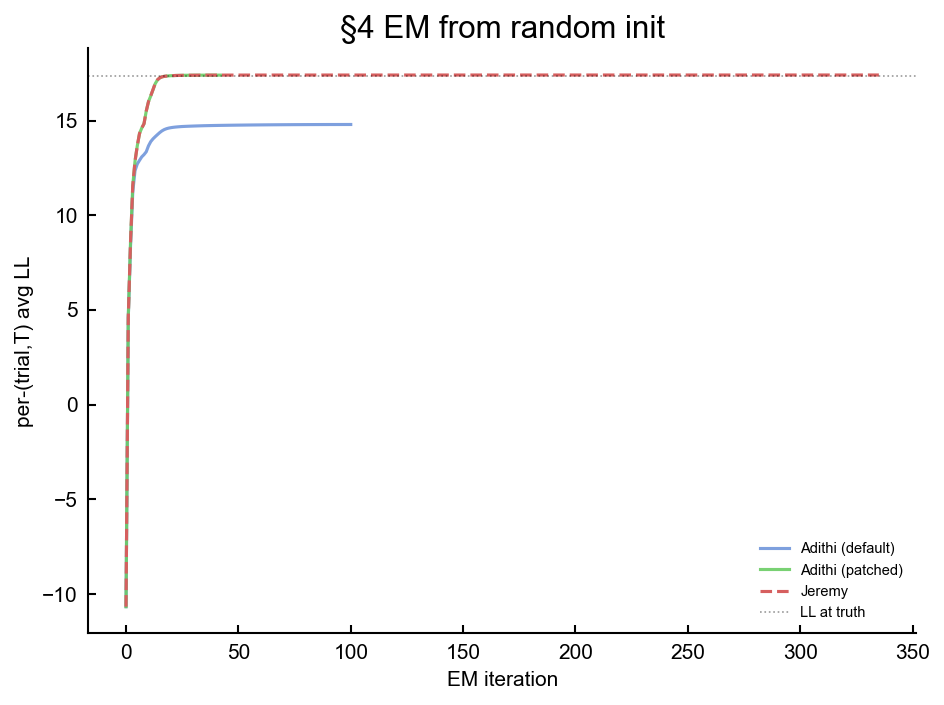

In [18]:
plt.plot(lls_default, label='Adithi (default)', color='C0', alpha=0.7)
plt.plot(lls_patched, label='Adithi (patched)', color='C2', alpha=0.9)
plt.plot(jeremys_model.ll_history, label='Jeremy', color='C3', ls='--')
plt.axhline(true_model_train_LL, color='k', alpha=0.4, lw=0.8, ls=':', label='LL at truth')
plt.xlabel('EM iteration')
plt.ylabel('per-(trial,T) avg LL')
plt.title('§4 EM from random init')
plt.legend(frameon=False)
plt.gca().spines[['top', 'right']].set_visible(False)


## 5. EM from NMF initialization

Same as §4 but the local model gets its EIRNN/NMF data-driven warm start instead of random init. We push those NMF-init params into both ssm models so all three start from the same point. Compare the LL trajectories — patched ssm should track Jeremy; default ssm sits below both.


In [19]:
adithis_default = ssm_lds.LDS(
    N=N, D=D, M=0,
    dynamics='gaussian_ctds',
    emissions='gaussian_ctds',
    emission_kwargs=emission_kwargs,
    dynamics_kwargs=dynamics_kwargs,
)
adithis_patched = ssm_lds.LDS(
    N=N, D=D, M=0,
    dynamics='gaussian_ctds',
    emissions='gaussian_ctds',
    emission_kwargs=emission_kwargs,
    dynamics_kwargs=dynamics_kwargs,
)
patch_ssm_ctds(adithis_patched)

jeremys_model = CTDS(
    De=De, Di=Di, Ne=Ne, Ni=Ni,
    fit_mu0=False, fit_b=False, fit_d_bias=True,
)
jeremys_model.init_params(Y_train)
jeremys_model.mu0 = np.zeros((D, 1))

def _push_jeremys_init(m):
    m.dynamics.As[0] = jeremys_model.A
    m.dynamics.bs[0] = jeremys_model.b[:, 0]
    m.dynamics._sqrt_Sigmas[0] = np.linalg.cholesky(jeremys_model.Q)
    m.dynamics.mu_init[0] = jeremys_model.mu0[:, 0]
    m.dynamics.Sigmas_init = np.array([jeremys_model.Q0])
    m.emissions.Cs[0] = jeremys_model.C
    m.emissions.ds[0] = jeremys_model.d_bias[:, 0]
    m.emissions.inv_etas[0] = jeremys_model.R

_push_jeremys_init(adithis_default)
_push_jeremys_init(adithis_patched)

lls_default, _ = adithis_default.fit(train_datas, method="laplace_em", num_iters=100, initialize=False)
lls_patched, _ = adithis_patched.fit(train_datas, method="laplace_em", num_iters=100, initialize=False)

jeremys_model.fit(Y_train, verbose=True, criterion=1e-6)


Assuming Dale's constraints for the weights within regions
Assuming FOF-ADS cross-region constraints if 2 regions, otherwise no cross-region constraints
Assuming Dale's constraints for the weights within regions
Assuming FOF-ADS cross-region constraints if 2 regions, otherwise no cross-region constraints


  0%|          | 0/100 [00:00<?, ?it/s]

Converged at iteration 15


  0%|          | 0/100 [00:00<?, ?it/s]

Converged at iteration 40
Iteration 0: LL = 14.060743
Iteration 1: LL = 16.481628
Iteration 2: LL = 16.757532
Iteration 3: LL = 16.922012
Iteration 4: LL = 17.036315
Iteration 5: LL = 17.114880
Iteration 6: LL = 17.166072
Iteration 7: LL = 17.198893
Iteration 8: LL = 17.221541
Iteration 9: LL = 17.239864
Iteration 10: LL = 17.257260
Iteration 11: LL = 17.275177
Iteration 12: LL = 17.293639
Iteration 13: LL = 17.311608
Iteration 14: LL = 17.327667
Iteration 15: LL = 17.340866
Iteration 16: LL = 17.351068
Iteration 17: LL = 17.358740
Iteration 18: LL = 17.364501
Iteration 19: LL = 17.368882
Iteration 20: LL = 17.372268
Iteration 21: LL = 17.374926
Iteration 22: LL = 17.377038
Iteration 23: LL = 17.378739
Iteration 24: LL = 17.380121
Iteration 25: LL = 17.381260
Iteration 26: LL = 17.382207
Iteration 27: LL = 17.383002
Iteration 28: LL = 17.383680
Iteration 29: LL = 17.384258
Iteration 30: LL = 17.384757
Iteration 31: LL = 17.385191
Iteration 32: LL = 17.385570
Iteration 33: LL = 17.38590

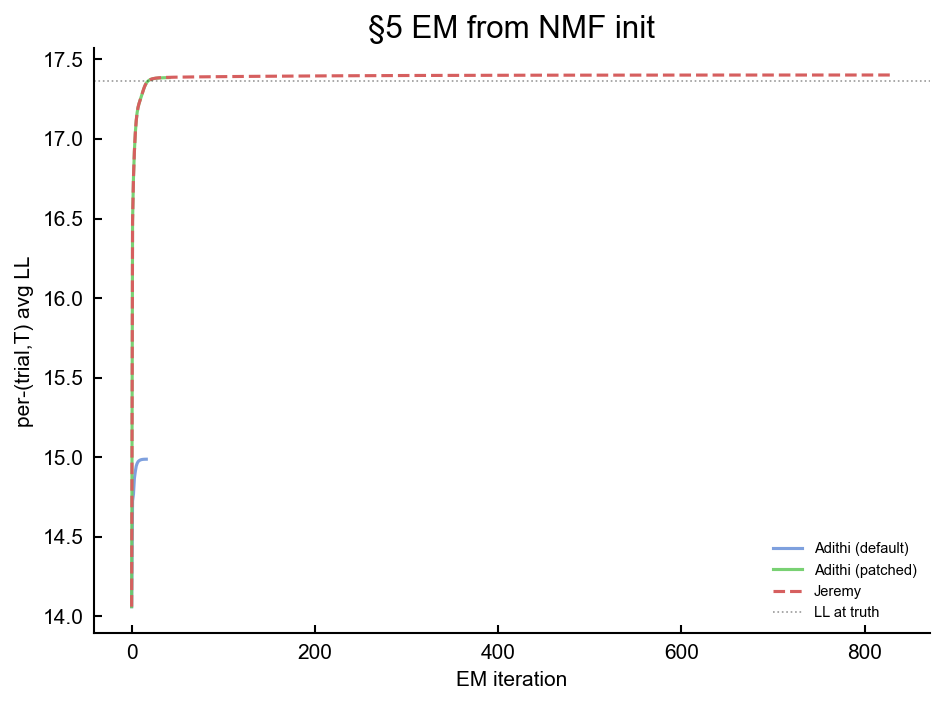

In [20]:
plt.plot(lls_default, label='Adithi (default)', color='C0', alpha=0.7)
plt.plot(lls_patched, label='Adithi (patched)', color='C2', alpha=0.9)
plt.plot(jeremys_model.ll_history, label='Jeremy', color='C3', ls='--')
plt.axhline(true_model_train_LL, color='k', alpha=0.4, lw=0.8, ls=':', label='LL at truth')
plt.xlabel('EM iteration')
plt.ylabel('per-(trial,T) avg LL')
plt.title('§5 EM from NMF init')
plt.legend(frameon=False)
plt.gca().spines[['top', 'right']].set_visible(False)


## 5a. Parameter inventory: who fits what

Pull every fitted parameter from the §5 fits of all three models. Compare to truth (raw, NOT C-aligned). The patched-vs-Jeremy row should agree to ~1e-3 Frobenius; the default row will be substantially off because of the four M-step bugs.


Frobenius distance from TRUTH (smaller = closer to ground truth):
param           default        patched         Jeremy
--------------------------------------------------------
A            2.5874e+00     2.7945e+00     2.4948e+00
b            0.0000e+00     0.0000e+00     0.0000e+00
Q            2.7907e-01     6.4165e-02     6.3356e-02
C            2.3801e+00     2.2878e+00     2.1192e+00
d            2.7765e-03     2.3810e-03     7.7314e-03
R            1.7235e-03     1.3419e-04     8.7867e-05
mu0          0.0000e+00     0.0000e+00     0.0000e+00
Q0           8.2616e+00     7.9463e+00     7.1229e+00

Frobenius distance Adithi-patched <-> Jeremy (smaller = patched matches local):
param        pat vs jer
----------------------------
A            4.1185e-01
b            0.0000e+00
Q            1.0849e-02
C            4.1025e-01
d            6.2253e-03
R            5.2777e-05
mu0          0.0000e+00
Q0           9.5318e-01


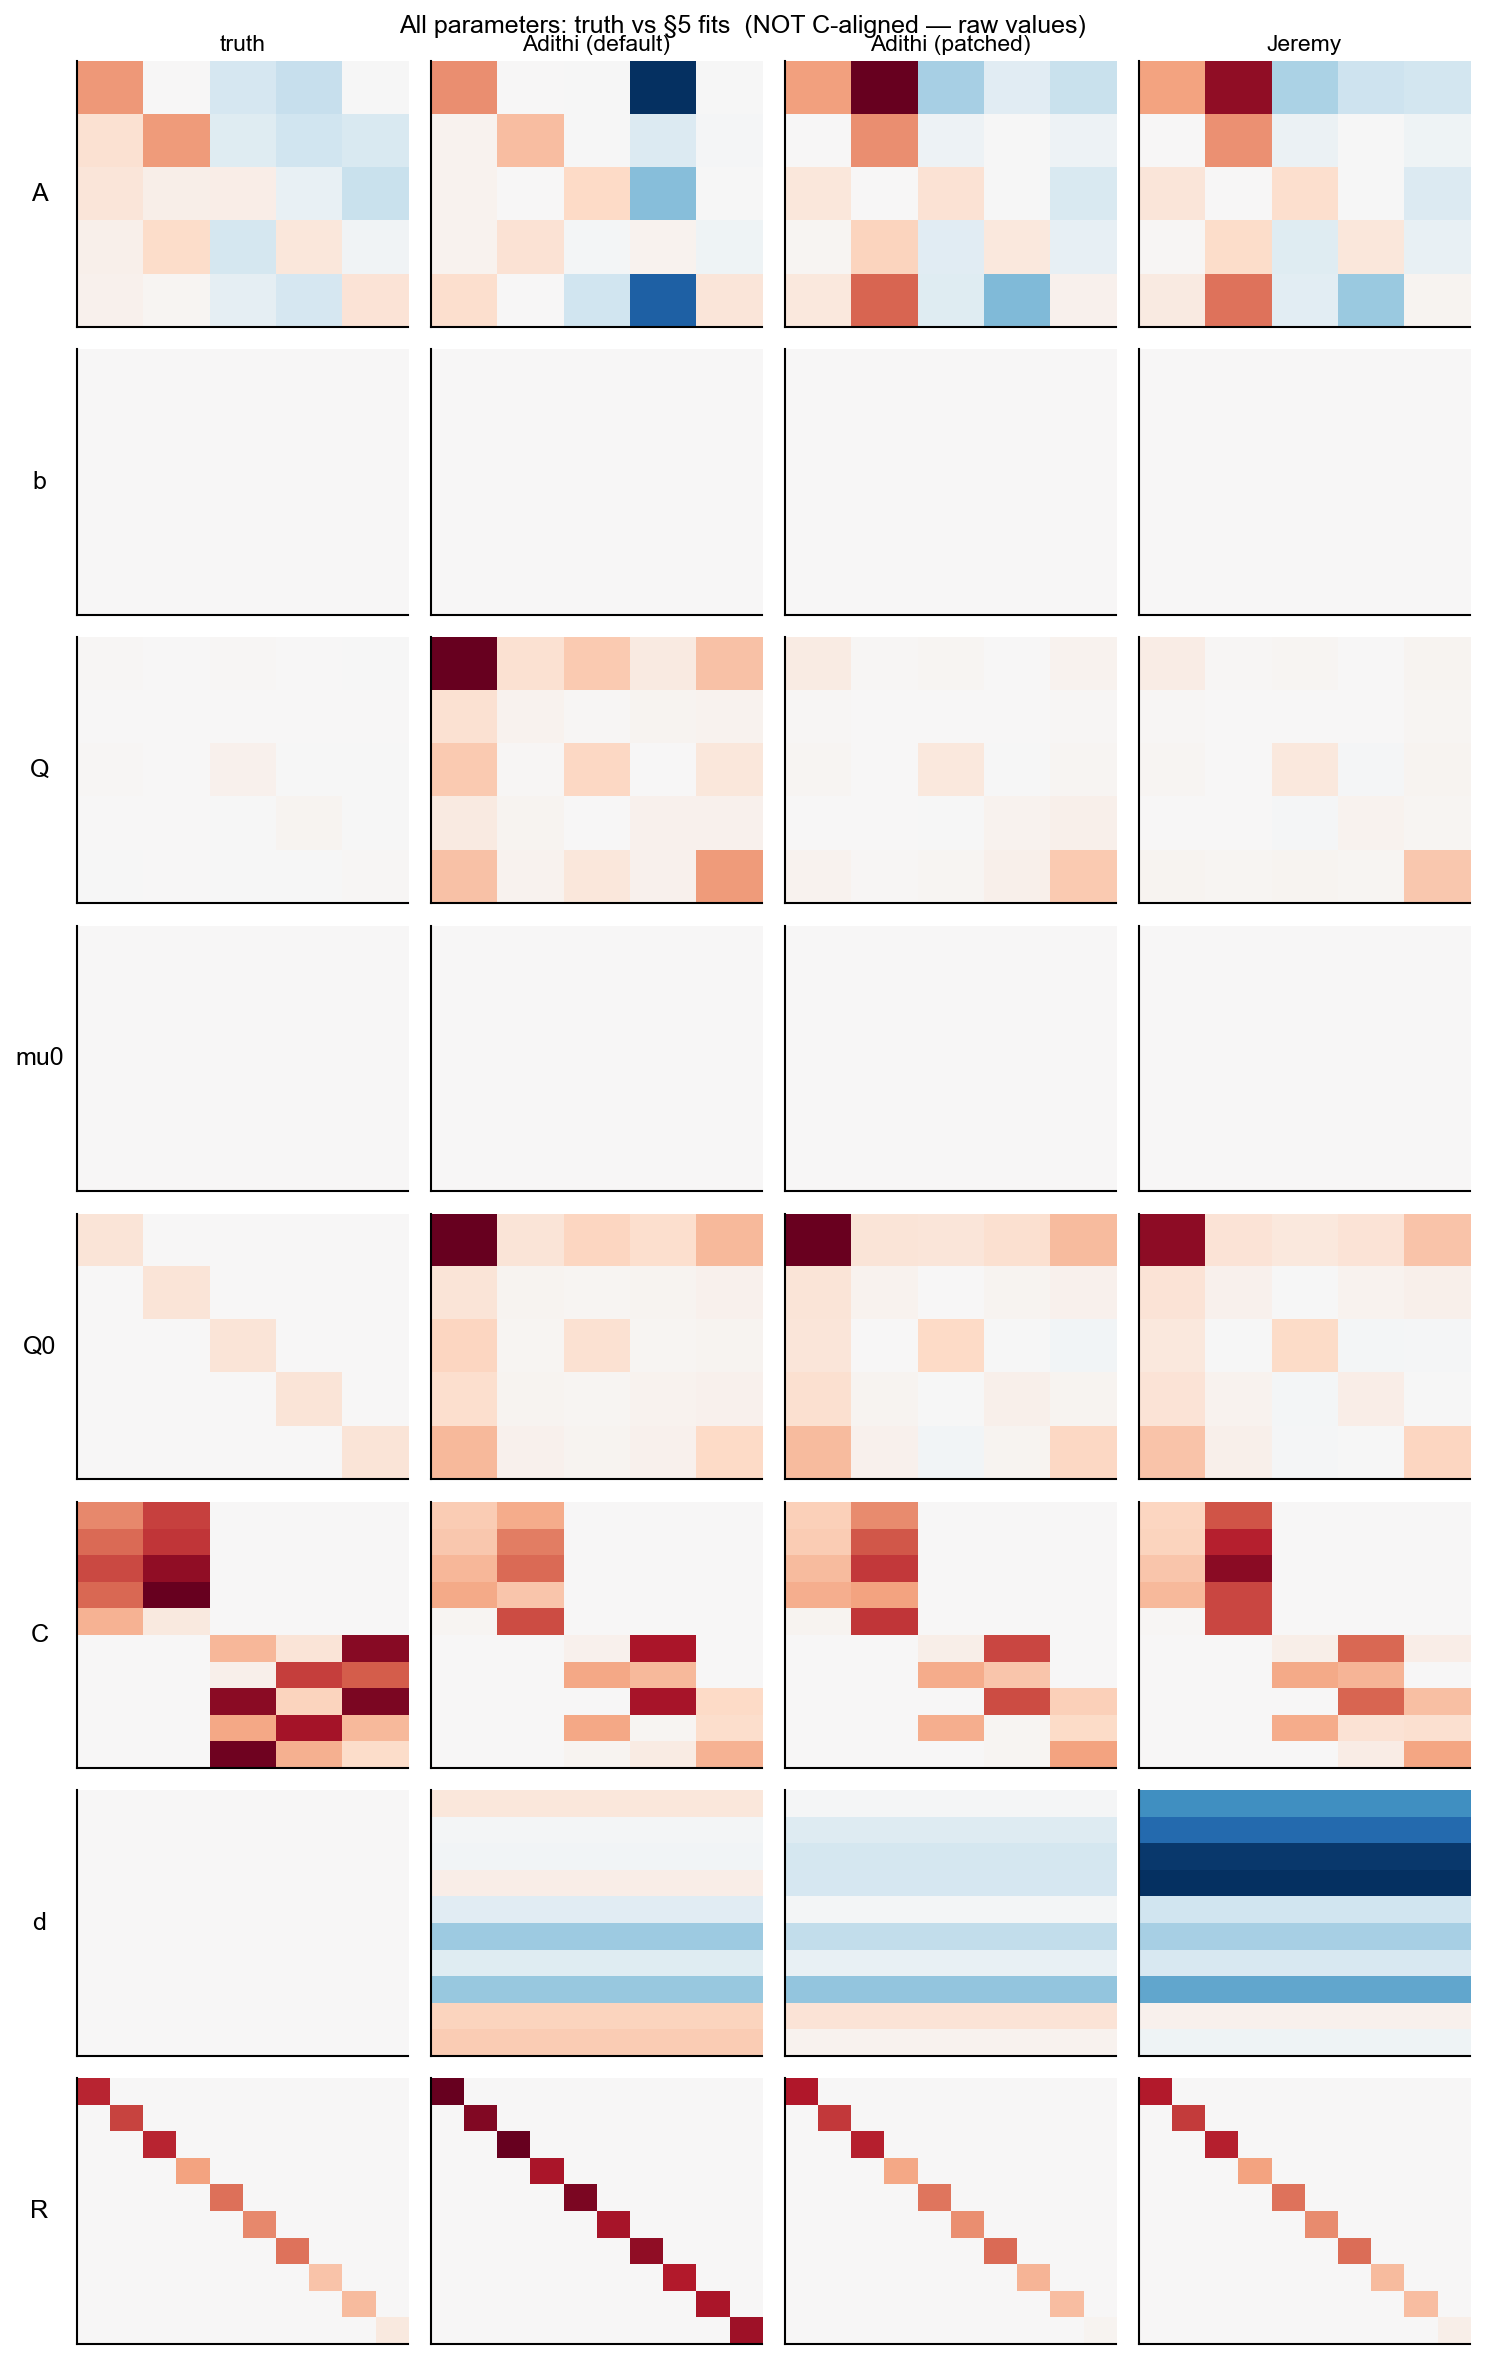

In [21]:
# --- Pull every parameter from all three §5 fits, compare to truth ---

# Adithi default (vendored ssm, has bugs)
A_def  = adithis_default.dynamics.As[0]
b_def  = adithis_default.dynamics.bs[0]
Q_def  = adithis_default.dynamics.Sigmas[0]
mu0_def = adithis_default.dynamics.mu_init[0]
Q0_def = adithis_default.dynamics.Sigmas_init[0]
C_def  = adithis_default.emissions.Cs[0]
d_def  = adithis_default.emissions.ds[0]
R_def  = adithis_default.emissions.inv_etas[0]

# Adithi patched (bugs fixed — should agree with Jeremy)
A_pat  = adithis_patched.dynamics.As[0]
b_pat  = adithis_patched.dynamics.bs[0]
Q_pat  = adithis_patched.dynamics.Sigmas[0]
mu0_pat = adithis_patched.dynamics.mu_init[0]
Q0_pat = adithis_patched.dynamics.Sigmas_init[0]
C_pat  = adithis_patched.emissions.Cs[0]
d_pat  = adithis_patched.emissions.ds[0]
R_pat  = adithis_patched.emissions.inv_etas[0]

# Jeremy
A_jer = jeremys_model.A
b_jer = jeremys_model.b[:, 0]
Q_jer = jeremys_model.Q
mu0_jer = jeremys_model.mu0[:, 0]
Q0_jer = jeremys_model.Q0
C_jer = jeremys_model.C
d_jer = jeremys_model.d_bias[:, 0]
R_jer = jeremys_model.R

def fro(x, y):
    return float(np.linalg.norm(np.asarray(x) - np.asarray(y)))

print('Frobenius distance from TRUTH (smaller = closer to ground truth):')
print(f"{'param':<8} {'default':>14} {'patched':>14} {'Jeremy':>14}")
print('-' * 56)
for name, vt, vd, vp, vj in [
    ('A',   A_true,                 A_def, A_pat, A_jer),
    ('b',   np.zeros(D),            b_def, b_pat, b_jer),
    ('Q',   Q_true,                 Q_def, Q_pat, Q_jer),
    ('C',   C_true,                 C_def, C_pat, C_jer),
    ('d',   np.zeros(N),            d_def, d_pat, d_jer),
    ('R',   R_true,                 R_def, R_pat, R_jer),
    ('mu0', mu0_true[:, 0],         mu0_def, mu0_pat, mu0_jer),
    ('Q0',  Q0_true,                Q0_def, Q0_pat, Q0_jer),
]:
    print(f'{name:<8} {fro(vd, vt):14.4e} {fro(vp, vt):14.4e} {fro(vj, vt):14.4e}')

print()
print('Frobenius distance Adithi-patched <-> Jeremy (smaller = patched matches local):')
print(f"{'param':<8} {'pat vs jer':>14}")
print('-' * 28)
for name, vp, vj in [
    ('A',   A_pat, A_jer),
    ('b',   b_pat, b_jer),
    ('Q',   Q_pat, Q_jer),
    ('C',   C_pat, C_jer),
    ('d',   d_pat, d_jer),
    ('R',   R_pat, R_jer),
    ('mu0', mu0_pat, mu0_jer),
    ('Q0',  Q0_pat, Q0_jer),
]:
    print(f'{name:<8} {fro(vp, vj):14.4e}')

# --- Heatmap grid: rows = params, cols = (truth, default, patched, jeremy) ---
def col(v):
    v = np.asarray(v)
    return v.reshape(-1, 1) if v.ndim == 1 else v

panels = [
    ('A',   A_true,                 A_def,            A_pat,            A_jer),
    ('b',   col(np.zeros(D)),       col(b_def),       col(b_pat),       col(b_jer)),
    ('Q',   Q_true,                 Q_def,            Q_pat,            Q_jer),
    ('mu0', col(mu0_true[:, 0]),    col(mu0_def),     col(mu0_pat),     col(mu0_jer)),
    ('Q0',  Q0_true,                Q0_def,           Q0_pat,           Q0_jer),
    ('C',   C_true,                 C_def,            C_pat,            C_jer),
    ('d',   col(np.zeros(N)),       col(d_def),       col(d_pat),       col(d_jer)),
    ('R',   R_true,                 R_def,            R_pat,            R_jer),
]

n_rows = len(panels)
fig, axes = plt.subplots(n_rows, 4, figsize=(10, 2.0 * n_rows))
col_titles = ['truth', "Adithi (default)", "Adithi (patched)", "Jeremy"]

for r, (name, T_, D_, P_, J_) in enumerate(panels):
    vmax = max(np.abs(x).max() for x in [T_, D_, P_, J_]) or 1.0
    for c, M in enumerate([T_, D_, P_, J_]):
        ax = axes[r, c]
        ax.imshow(M, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0:
            ax.set_title(col_titles[c], fontsize=11)
        if c == 0:
            ax.set_ylabel(name, rotation=0, labelpad=18, fontsize=12, va='center')

fig.suptitle('All parameters: truth vs §5 fits  (NOT C-aligned — raw values)', fontsize=12)
fig.tight_layout()


## 5b. Sanity check: ssm warm-started at ground truth

Push the true params into all three models and run a fixed number of EM iterations. Plot the LL trajectory of each against the exact LL at truth. ssm-default should drift from truth (because of the M-step bugs documented in §3a); ssm-patched and Jeremy should both stay near truth and climb together toward the MLE.


Assuming Dale's constraints for the weights within regions
Assuming FOF-ADS cross-region constraints if 2 regions, otherwise no cross-region constraints
Assuming Dale's constraints for the weights within regions
Assuming FOF-ADS cross-region constraints if 2 regions, otherwise no cross-region constraints
exact LL at truth (train): 17.367428


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]


                         final train LL
----------------------------------------
Adithi default                15.015502
Adithi patched                17.402266
Jeremy                        17.402266
LL at truth params            17.367428


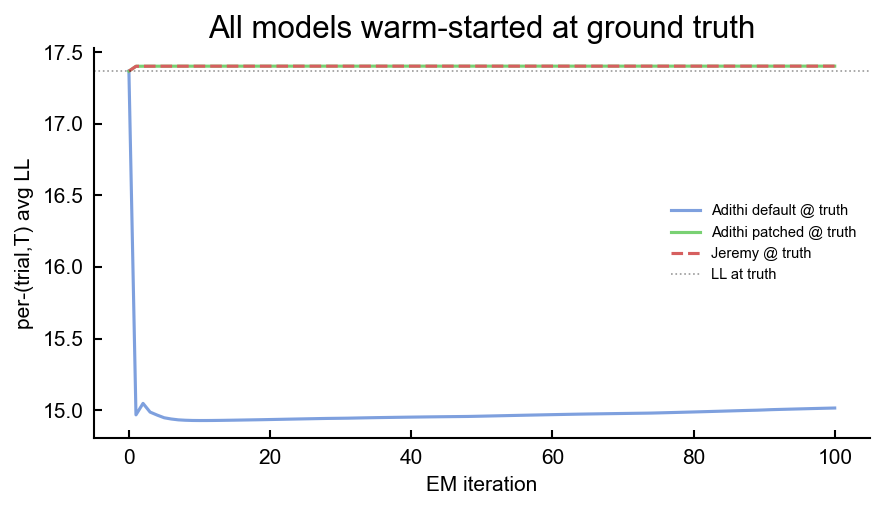

In [22]:
# The MLE on the training set is by definition >= LL_at_truth, so ssm climbing
# above truth proves nothing. The real question: starting from truth, do
# ssm-default, ssm-patched, and Jeremy converge to the same LL?
truth_default = ssm_lds.LDS(
    N=N, D=D, M=0,
    dynamics='gaussian_ctds',
    emissions='gaussian_ctds',
    emission_kwargs=emission_kwargs,
    dynamics_kwargs=dynamics_kwargs,
)
truth_patched = ssm_lds.LDS(
    N=N, D=D, M=0,
    dynamics='gaussian_ctds',
    emissions='gaussian_ctds',
    emission_kwargs=emission_kwargs,
    dynamics_kwargs=dynamics_kwargs,
)
patch_ssm_ctds(truth_patched)

for m in (truth_default, truth_patched):
    m.dynamics.As[0] = A_true
    m.dynamics.bs[0] = 0
    m.dynamics._sqrt_Sigmas[0] = np.linalg.cholesky(Q_true)
    m.dynamics.mu_init[0] = mu0_true[:, 0]
    m.dynamics.Sigmas_init = np.array([Q0_true])
    m.emissions.Cs[0] = C_true
    m.emissions.ds[0] = 0
    m.emissions.inv_etas[0] = R_true

ll_truth = truth_default.log_likelihood(train_datas)
print(f'exact LL at truth (train): {ll_truth:.6f}')

n_iters = 100

def_warm_lls = [truth_default.log_likelihood(train_datas)]
pat_warm_lls = [truth_patched.log_likelihood(train_datas)]
for _ in range(n_iters):
    truth_default.fit(train_datas, method='laplace_em', num_iters=1, initialize=False)
    truth_patched.fit(train_datas, method='laplace_em', num_iters=1, initialize=False)
    def_warm_lls.append(truth_default.log_likelihood(train_datas))
    pat_warm_lls.append(truth_patched.log_likelihood(train_datas))

jeremy_warm = CTDS(
    De=De, Di=Di, Ne=Ne, Ni=Ni,
    fit_mu0=False, fit_b=False, fit_d_bias=True,
)
jeremy_warm.A = A_true.copy()
jeremy_warm.C = C_true.copy()
jeremy_warm.Q = Q_true.copy()
jeremy_warm.R = R_true.copy()
jeremy_warm.mu0 = mu0_true.copy()
jeremy_warm.Q0 = Q0_true.copy()
jeremy_warm.b = np.zeros((D, 1))
jeremy_warm.d_bias = np.zeros((N, 1))
jeremy_warm.fit(Y_train, max_iter=n_iters, criterion=-np.inf, verbose=False)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(def_warm_lls, label='Adithi default @ truth', color='C0', alpha=0.7)
ax.plot(pat_warm_lls, label='Adithi patched @ truth', color='C2', alpha=0.9)
ax.plot(jeremy_warm.ll_history, label='Jeremy @ truth', color='C3', ls='--')
ax.axhline(ll_truth, color='k', alpha=0.4, lw=0.8, ls=':', label='LL at truth')
ax.set(xlabel='EM iteration', ylabel='per-(trial,T) avg LL',
       title='All models warm-started at ground truth')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()

print()
print(f"{'':<22} {'final train LL':>16}")
print('-' * 40)
print(f"{'Adithi default':<22} {def_warm_lls[-1]:16.6f}")
print(f"{'Adithi patched':<22} {pat_warm_lls[-1]:16.6f}")
print(f"{'Jeremy':<22} {jeremy_warm.ll_history[-1]:16.6f}")
print(f"{'LL at truth params':<22} {ll_truth:16.6f}")


## 6. Aligned parameter recovery

Latents are only identifiable up to invertible $H \in \mathbb{R}^{D\times D}$. Solve for $H = (C_{\text{fit}}^\top C_{\text{fit}})^{-1} C_{\text{fit}}^\top C_{\text{true}}$ once per fit, then compare:
- $A_{\text{aligned}} = H^{-1} A_{\text{fit}} H$
- $C_{\text{aligned}} = C_{\text{fit}} H$
- $Q_{\text{aligned}} = H^{-1} Q_{\text{fit}} H^{-\top}$
- $R$ doesn't transform (observation-space).

This is the same alignment used in [scripts/ctds_recovery.py](../scripts/ctds_recovery.py). Adithi's repo uses a different scheme (per-block correlation-based permutation + per-column scaling, see `transform_true_rec` in [vendor/Cell_type_dynamical_system/utils/simulation_utils.py](../vendor/Cell_type_dynamical_system/utils/simulation_utils.py)) — fine to use either, but use the **same** one for both fits to keep the comparison fair.

Reference fit lives at:
- `ref.dynamics.As[0]`, `ref.dynamics.Sigmas[0]` (note: `Sigmas`, not `_sqrt_Sigmas`)
- `ref.emissions.Cs[0]`, `ref.emissions.inv_etas[0]` (which IS the covariance R for this emission class)

Print MSEs in a table; show A and C heatmaps side by side (true + 4 fits).

In [23]:
def align(A_fit, C_fit, Q_fit, R_fit, C_true):
    """Align via H = (C'^T C')^-1 C'^T C_true. R is observation-space, doesn't transform."""
    H = np.linalg.inv(C_fit.T @ C_fit) @ C_fit.T @ C_true
    H_inv = np.linalg.inv(H)
    return H_inv @ A_fit @ H, C_fit @ H, H_inv @ Q_fit @ H_inv.T, R_fit

# Pull out fitted params from both models.
A_a_raw = adithis_model.dynamics.As[0]
C_a_raw = adithis_model.emissions.Cs[0]
Q_a_raw = adithis_model.dynamics.Sigmas[0]
R_a_raw = adithis_model.emissions.inv_etas[0]

A_a, C_a, Q_a, R_a = align(A_a_raw, C_a_raw, Q_a_raw, R_a_raw, C_true)
A_j, C_j, Q_j, R_j = align(jeremys_model.A, jeremys_model.C, jeremys_model.Q, jeremys_model.R, C_true)

mats = [
    ('A', A_true, A_a, A_j),
    ('C', C_true, C_a, C_j),
    ('Q', Q_true, Q_a, Q_j),
    ('R', R_true, R_a, R_j),
]
col_titles = ['true', "Adithi's fit", "Jeremy's fit"]

fig, axes = plt.subplots(4, 3, figsize=(9, 11))
for row, (name, t, a, j) in enumerate(mats):
    vmax = max(np.abs(t).max(), np.abs(a).max(), np.abs(j).max())
    for col, M in enumerate([t, a, j]):
        ax = axes[row, col]
        im = ax.imshow(M, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        if row == 0:
            ax.set_title(col_titles[col])
        if col == 0:
            ax.set_ylabel(name, rotation=0, labelpad=18, fontsize=14, va='center')
        ax.set_xticks([])
        ax.set_yticks([])
    # fig.colorbar(im, ax=axes[row].tolist(), shrink=0.85)

fig.suptitle('Recovered parameters (C-aligned to truth)')
fig.tight_layout()

# MSE table.
def mse(a, b):
    return float(np.mean((a - b) ** 2))

print(f'{"":<10} {"Adithi":>14} {"Jeremy":>14}')
print('-' * 40)
for name, t, a, j in mats:
    print(f'{name + " MSE":<10} {mse(a, t):14.6e} {mse(j, t):14.6e}')

NameError: name 'adithis_model' is not defined